x-ray image analysis using cnn

Dataset Link:https://www.kaggle.com/datasets/alifrahman/covid19-chest-xray-image-dataset

In [ ]:
!pip install opendatasets
import opendatasets as od
od.download("https://www.kaggle.com/datasets/alifrahman/covid19-chest-xray-image-dataset")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: riyaindap
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/alifrahman/covid19-chest-xray-image-dataset


100%|██████████| 40.6M/40.6M [00:00<00:00, 1.23GB/s]

import necessary libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2 as cv
import random

Investigating a single image from the Dataset:

In [ ]:
# def load_image(path):
#     for img in os.listdir(bacteria_path):
#         print('Image name =',img)
#         image = cv.imread(os.path.join(bacteria_path, img))
#         break

#     return image

Investigating single image

The dimensions are 1148 pixels height and 2563 pixels width
The maximum pixel value is 255.0000
The minimum pixel value is 20.0000
The mean value of the pixels is 111.8149
The standard deviation is 29.2850


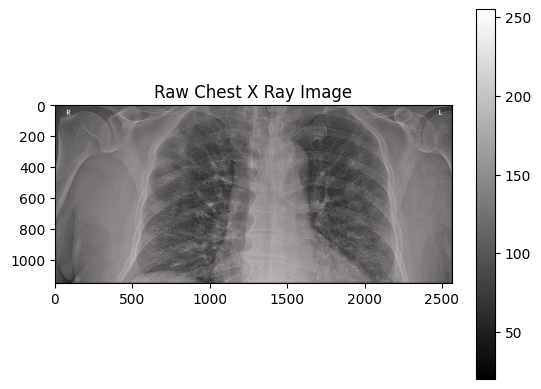

In [ ]:
from keras.preprocessing import image
bacteria_path = '/content/covid19-chest-xray-image-dataset/dataset/covid/1-s2.0-S0140673620303706-fx1_lrg.jpg'

image = cv.imread(bacteria_path)
plt.imshow(image, cmap='gray')
plt.colorbar()
plt.title('Raw Chest X Ray Image')
print(f"The dimensions are {image.shape[0]} pixels height and {image.shape[1]} pixels width")
print(f"The maximum pixel value is {image.max():.4f}")
print(f"The minimum pixel value is {image.min():.4f}")
print(f"The mean value of the pixels is {image.mean():.4f}")
print(f"The standard deviation is {image.std():.4f}")

plot histogram

/tmp/ipython-input-3000102515.py:1: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(image.ravel(),256,[0,256])


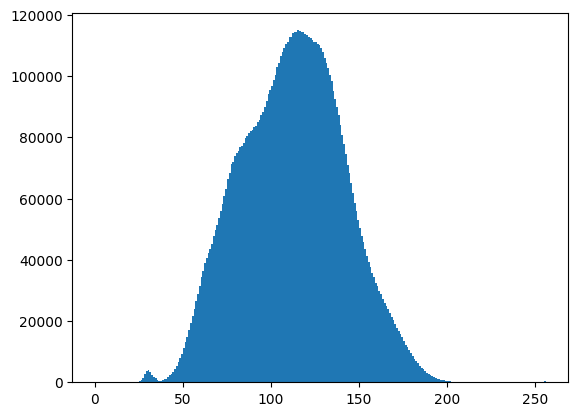

In [ ]:
plt.hist(image.ravel(),256,[0,256])
plt.show()

In [ ]:
!unzip data.zip

unzip:  cannot find or open data.zip, data.zip.zip or data.zip.ZIP.


Loading images and labels together and resizing images

In [ ]:
path = '/content/covid19-chest-xray-image-dataset/dataset'
folders=[]
folders = [f for f in sorted(os.listdir(path))]
print(folders)

['covid', 'normal']


In [ ]:
labels = folders
print (f'The labels are {labels}')
# setting the size of images that we want
image_size = 256
print(f'All images to be resized into {image_size}*{image_size} pixels')

The labels are ['covid', 'normal']
All images to be resized into 256*256 pixels


In [ ]:
# defining a function to load images and labels together
# this function will also resize the images

def load_train(path):
    X = []
    y = []
    for label in labels:
        direc = os.path.join(path, label)
        class_num = labels.index(label)
        for image in os.listdir(direc):
            image_read = cv.imread(os.path.join(direc,image),cv.IMREAD_GRAYSCALE)
            image_resized = cv.resize(image_read,(image_size,image_size))
            X.append(image_resized)
            y.append(class_num)
    return np.array(X), np.array(y)

In [ ]:
X, y = load_train(path)
print(f'Shape of the training images = {X.shape}')
print(f'Shape of the training labels = {y.shape}')

Shape of the training images = (94, 256, 256)
Shape of the training labels = (94,)


In [ ]:
# The images and labels are already loaded into X and y by the previous cell.
print (f'Length of X = {len(X)}')
print (f'Length of y = {len(y)}')

Length of X = 94
Length of y = 94


Number of Normal images = 69
Number of Covid images = 25


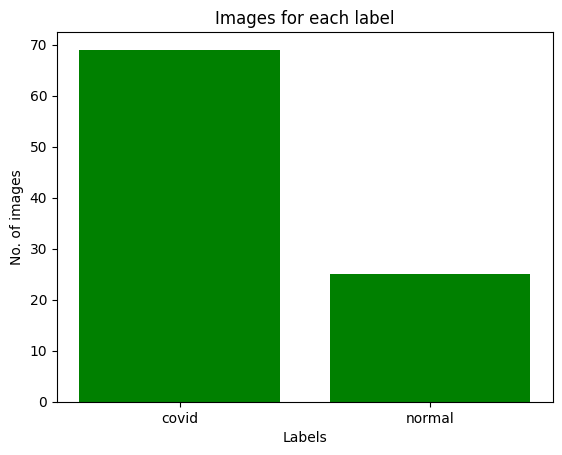

In [ ]:
# checking the number of images of each class
a = 0
b = 0
for label in y:
    if label == 0:
        a += 1
    if label == 1:
        b += 1
print (f'Number of Normal images = {a}')
print (f'Number of Covid images = {b}')

# plotting the data
x_pos = [i for i, _ in enumerate(labels)]
numbers = [a,b]
plt.bar(x_pos,numbers,color = 'green')
plt.xlabel("Labels")
plt.ylabel("No. of images")
plt.title("Images for each label")
plt.xticks(x_pos, labels)
plt.show()

Display Random Images


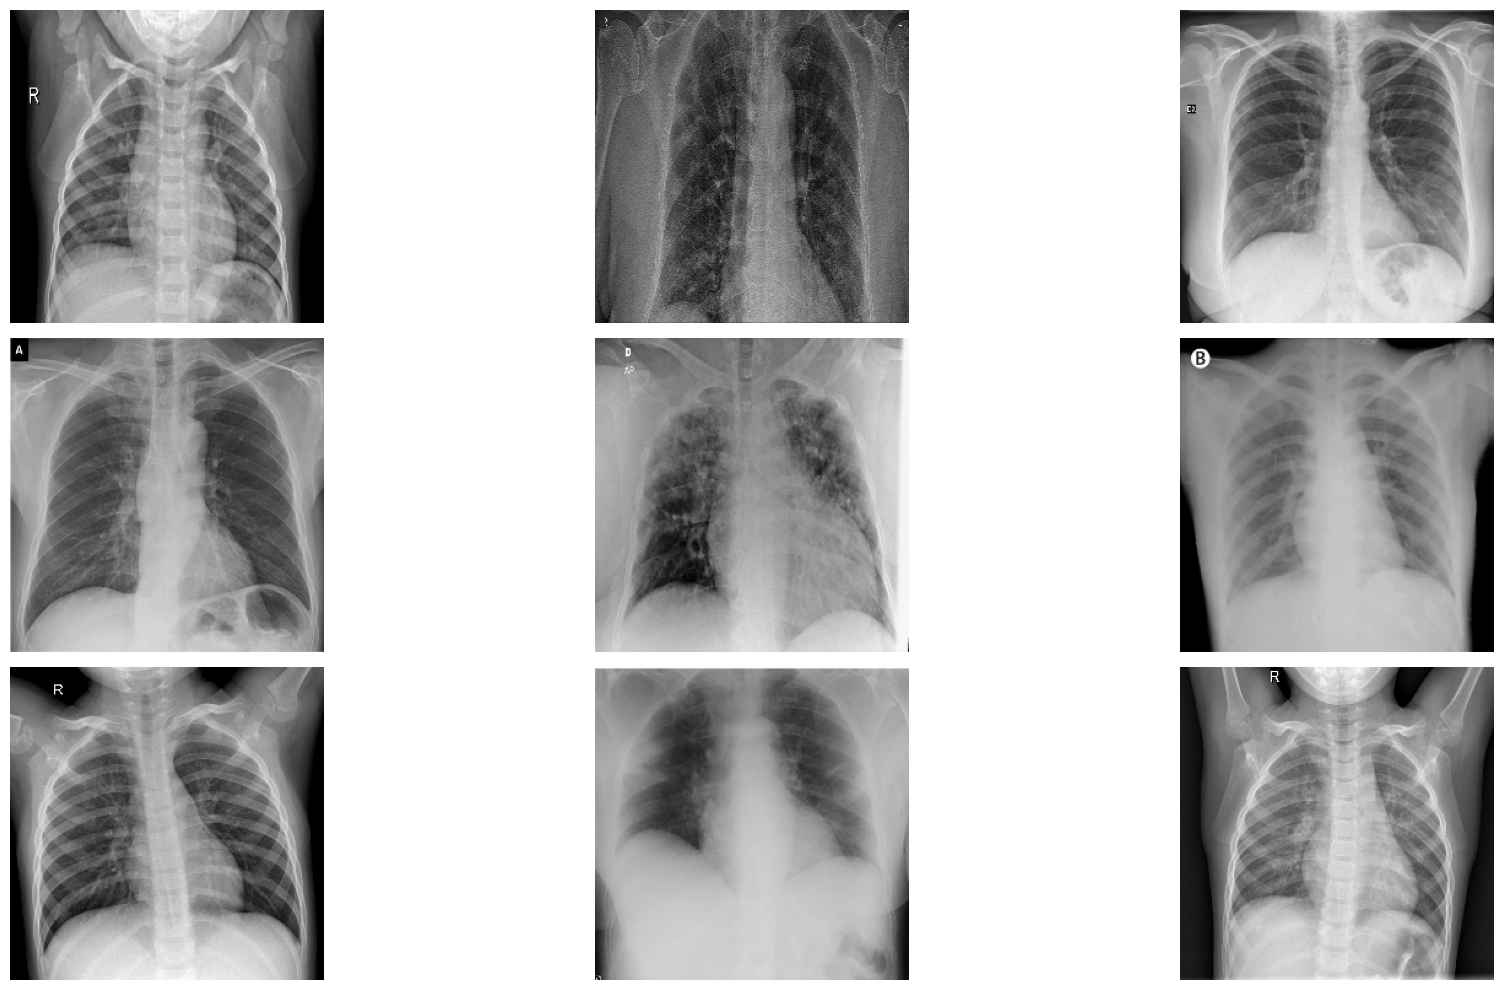

In [ ]:
# Displays images
# Extract 9 random images
print('Display Random Images')
# Adjust the size of your images
plt.figure(figsize=(20,10))
for i in range(9):
    num = random.randint(0,len(X)-1)
    plt.subplot(3, 3, i + 1)
    plt.imshow(X[num],cmap='gray')
    plt.axis('off')
# Adjust subplot parameters to give specified padding
plt.tight_layout()